# Southwest Australia — running example for the paper

This notebook is the canonical walk-through we use in the manuscript. It fits the
frequentist `GDM` and the Bayesian `spGDMM` to the Southwest Australia dataset
(94 sites, 865 plant species, Bray–Curtis dissimilarities, 3 environmental
predictors) and generates every figure/table we intend to include for SW.

**Data.** `examples/data/southwest/southwest_{sites,y}.csv` — the canonical
dataset from the R `gdm` package, pre-computed Bray–Curtis dissimilarities with
`vegan::vegdist`. Shipped alongside this notebook. White et al. (2024) Table 1
reports benchmarks for this exact split; we compare against them below.

**Model.** Best Bayesian configuration from Table 1:
`spatial_effect="squared_diff"` + `variance="homogeneous"` (Model 7). Matches
White's reported best RMSE/MAE for SW. Priors and sampler settings follow
`CLAUDE.md`: `LogNormal(0, 10)` on `beta`, `Normal(0, 10)` on `beta_sigma`,
`alpha_importance=False`.

**Running this notebook.** The Bayesian fit runs live — the notebook is
self-contained. By default it uses a moderate sampler config (`draws=500`,
`tune=1500`, `chains=2`) so it completes in a few minutes; flip
`FULL_SAMPLING = True` in the setup cell for the manuscript-scale fit
(`draws=1000`, `tune=4000`, `chains=4`). **Run the notebook inside a compute
allocation**, not on a login node — MCMC will otherwise bog down the shared
host.

## 1. Setup

In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.model_selection import KFold

from gdmbayes import (
    GDM,
    GDMPreprocessor,
    ModelConfig,
    SamplerConfig,
    crps_boxplot,
    plot_isplines,
    plot_link_curve,
    plot_obs_vs_pred,
    plot_ppc,
    plot_predictor_importance,
    rgb_biological_space,
    spGDMM,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Locate the repo root so paths work whether the notebook is launched from
# examples/ or from the repo root.
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "src" / "gdmbayes").exists() else NB_DIR.parent
assert (REPO_ROOT / "src" / "gdmbayes").exists(), f"couldn't find repo root from {NB_DIR}"

DATA_DIR = REPO_ROOT / "examples" / "data" / "southwest"
RESULTS_DIR = REPO_ROOT / "results" / "southwest"
FIG_DIR = REPO_ROOT / "paper" / "figures" / "southwest"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

# Flip to True to reproduce the manuscript-scale fit (draws=1000, tune=4000,
# chains=4). Default is a moderate config that runs in a few minutes.
FULL_SAMPLING = False

print(f"Repo root:   {REPO_ROOT}")
print(f"Data dir:    {DATA_DIR}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Figure dir:  {FIG_DIR}")

Repo root:   /cluster/home/haroldh/spgdmm
Data dir:    /cluster/home/haroldh/spgdmm/examples/data/southwest
Results dir: /cluster/home/haroldh/spgdmm/results/southwest
Figure dir:  /cluster/home/haroldh/spgdmm/paper/figures/southwest


## 2. Load the Southwest Australia data

We use exactly the three predictors White et al. (2024) report for SW:
`phTotal`, `bio5` (max temperature of warmest month), `bio19` (winter
precipitation). Geographic coordinates are `Long`/`Lat` → `xc`/`yc`, with
`time_idx = 0` (single-snapshot dataset).

In [2]:
ENV_PREDICTORS = ["phTotal", "bio5", "bio19"]

sites = pd.read_csv(DATA_DIR / "southwest_sites.csv")
y = pd.read_csv(DATA_DIR / "southwest_y.csv")["y"].to_numpy()

X = sites.rename(columns={"Long": "xc", "Lat": "yc"}).copy()
X["time_idx"] = 0
X = X[["xc", "yc", "time_idx", *ENV_PREDICTORS]]

n_sites = len(X)
n_pairs = len(y)
print(f"{n_sites} sites · {n_pairs} pairs · y ∈ [{y.min():.3f}, {y.max():.3f}]")
print(f"Saturated pairs (y == 1): {(y == 1.0).sum()}")
X.describe().round(2)

94 sites · 4371 pairs · y ∈ [0.331, 1.000]
Saturated pairs (y == 1): 138


,xc,yc,time_idx,phTotal,bio5,bio19
count,94.00,94.00,94.0,94.00,94.00,94.00
mean,117.47,-32.13,0.0,674.98,31.77,227.05
std,1.33,1.49,0.0,303.39,2.70,120.06
min,114.99,-34.75,0.0,277.98,25.57,114.39
25%,116.41,-33.38,0.0,473.05,30.17,135.30
50%,117.44,-32.17,0.0,584.61,32.16,172.42
75%,118.51,-30.94,0.0,800.44,33.90,297.62
max,119.98,-29.40,0.0,1860.37,36.19,554.77


### Site map

Quick look at the spatial layout — 94 sites spread across SW Australia, coloured
by `bio19` (winter precipitation, the strongest gradient in the dataset).

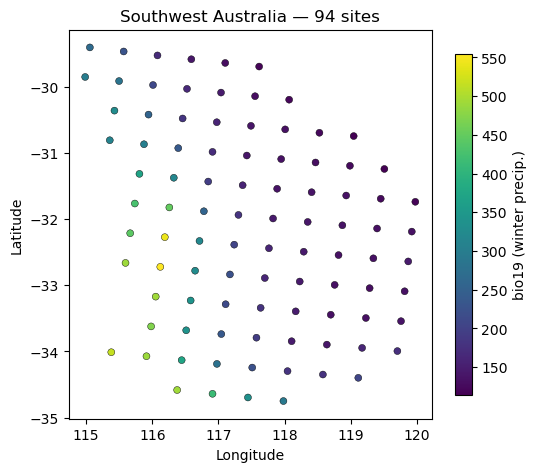

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(X["xc"], X["yc"], c=X["bio19"], cmap="viridis", s=25, edgecolor="k", lw=0.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Southwest Australia — 94 sites")
ax.set_aspect("equal")
fig.colorbar(sc, ax=ax, label="bio19 (winter precip.)", shrink=0.8)
fig.tight_layout()
fig.savefig(FIG_DIR / "sw_site_map.pdf")
plt.show()

## 3. Frequentist GDM (full-data fit)

`GDM` is the sklearn-style frequentist estimator: I-spline features + NNLS.
Settings (`deg=3`, `knots=1`, `geo=True`) match White et al.'s R `gdm` call for
SW so the benchmark comparison is apples-to-apples.

In [4]:
def make_gdm() -> GDM:
    return GDM(geo=True, splines=3, knots=1)

gdm = make_gdm()
gdm.fit(X, y)
y_pred_gdm = gdm.predict(X)

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

corr_gdm, _ = pearsonr(y, y_pred_gdm)
print(f"Deviance explained : {gdm.explained_:.4f}")
print(f"RMSE (train)       : {rmse(y, y_pred_gdm):.4f}")
print(f"MAE  (train)       : {mae(y, y_pred_gdm):.4f}")
print(f"Pearson r (train)  : {corr_gdm:.4f}")
print("\nPredictor importance:")
for k, v in gdm.predictor_importance_.items():
    print(f"  {k:12s} {v:.4f}")

Deviance explained : 0.7605
RMSE (train)       : 0.0586
MAE  (train)       : 0.0421
Pearson r (train)  : 0.8654

Predictor importance:
  phTotal      1.8785
  bio5         0.5697
  bio19        2.6440
  geo          0.7801


### 10-fold site-level CV (frequentist baseline)

Site-level folds: at each split, test *sites* are held out and every pair
touching a test site is a test pair. `GDMPreprocessor.site_pairs` produces the
pair indices for a given subset of sites.

In [5]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
y_pred_cv = np.full(n_pairs, np.nan)

for fold, (train_sites, test_sites) in enumerate(kf.split(np.arange(n_sites))):
    train_idx = GDMPreprocessor.site_pairs(n_sites, train_sites)
    test_idx = GDMPreprocessor.site_pairs(n_sites, test_sites)
    gdm_cv = make_gdm()
    gdm_cv.fit(X.iloc[train_sites].reset_index(drop=True), y[train_idx])
    y_pred_cv[test_idx] = gdm_cv.predict(X.iloc[test_sites].reset_index(drop=True))

mask = ~np.isnan(y_pred_cv)
freq_cv = {
    "RMSE": rmse(y[mask], y_pred_cv[mask]),
    "MAE": mae(y[mask], y_pred_cv[mask]),
}
print("10-fold CV (frequentist GDM)")
print(f"  RMSE = {freq_cv['RMSE']:.4f}   (White 2024 Ferrier: 0.0737)")
print(f"  MAE  = {freq_cv['MAE']:.4f}   (White 2024 Ferrier: 0.0549)")

/cluster/home/haroldh/spgdmm/src/gdmbayes/preprocessor.py:257: UserWarning: 2 env values were clipped to predictor_mesh bounds.
  warnings.warn(f"{n_clipped_env} env values were clipped to predictor_mesh bounds.")
/cluster/home/haroldh/spgdmm/src/gdmbayes/preprocessor.py:257: UserWarning: 1 env values were clipped to predictor_mesh bounds.
  warnings.warn(f"{n_clipped_env} env values were clipped to predictor_mesh bounds.")
/cluster/home/haroldh/spgdmm/src/gdmbayes/preprocessor.py:257: UserWarning: 1 env values were clipped to predictor_mesh bounds.
  warnings.warn(f"{n_clipped_env} env values were clipped to predictor_mesh bounds.")
/cluster/home/haroldh/spgdmm/src/gdmbayes/preprocessor.py:257: UserWarning: 1 env values were clipped to predictor_mesh bounds.
  warnings.warn(f"{n_clipped_env} env values were clipped to predictor_mesh bounds.")
/cluster/home/haroldh/spgdmm/src/gdmbayes/preprocessor.py:257: UserWarning: 1 env values were clipped to predictor_mesh bounds.
  warnings.warn(

10-fold CV (frequentist GDM)
  RMSE = 0.0631   (White 2024 Ferrier: 0.0737)
  MAE  = 0.0459   (White 2024 Ferrier: 0.0549)


## 4. Bayesian spGDMM — full-data fit

Best configuration from White Table 1 for SW:

| spatial_effect | variance    | Model # | RMSE  | CRPS  |
|----------------|-------------|:-------:|:-----:|:-----:|
| squared_diff   | homogeneous |   7     | 0.0731| 0.0414|

This cell runs the MCMC fit live. It uses the moderate sampler config by
default; set `FULL_SAMPLING = True` in the setup cell to reproduce the
manuscript-scale fit. The fit is cached to `results/southwest/` so re-running
the notebook reuses it rather than re-sampling.

In [6]:
FIT_TAG = "squared_diff_homogeneous"
fit_path = RESULTS_DIR / f"southwest_spgdmm_{FIT_TAG}.nc"

if FULL_SAMPLING:
    draws, tune, chains = 1000, 4000, 4
else:
    draws, tune, chains = 500, 1500, 2

def build_spgdmm() -> spGDMM:
    return spGDMM(
        preprocessor=GDMPreprocessor(
            deg=3, knots=1, mesh_choice="percentile", distance_measure="geodesic"
        ),
        model_config=ModelConfig(
            variance="homogeneous",
            spatial_effect="squared_diff",
            alpha_importance=False,
        ),
        sampler_config=SamplerConfig(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=0.95,
            nuts_sampler="nutpie",
            progressbar=True,
            random_seed=SEED,
        ),
    )

if fit_path.exists():
    print(f"Loading cached fit: {fit_path}")
    model = spGDMM.load(str(fit_path))
else:
    print(f"No cached fit — sampling now (draws={draws}, tune={tune}, chains={chains})")
    model = build_spgdmm()
    model.fit(X, y)
    model.save(str(fit_path))
    print(f"Saved → {fit_path}")

model

Loading cached fit: /cluster/home/haroldh/spgdmm/results/southwest/southwest_spgdmm_squared_diff_homogeneous.nc


/cluster/home/haroldh/miniforge3/envs/spgdmm/lib/python3.11/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Attributes (set After Fit)
  self[section] = content


,preprocessor,"GDMPreprocess...sic', knots=1)"
,model_config,"{'alpha_importance': False, 'spatial_effect': 'squared_diff', 'variance': 'homogeneous'}"
,sampler_config,"{'chains': 2, 'draws': 500, 'nuts_sampler': 'nutpie', 'progressbar': True, ...}"
,deg,3
,knots,1
,mesh_choice,'percentile'
,distance_measure,'geodesic'
,custom_dist_mesh,None
,custom_predictor_mesh,None
,extrapolation,'clip'


### 4a. Convergence and sampling diagnostics

`summarise_sampling()` returns a per-variable table of posterior mean, SD, HDI,
ESS, and R-hat — our first-pass check that NUTS mixed.

In [7]:
diag = model.summarise_sampling()
rhat_max = float(az.rhat(model.idata_).to_array().max())
print(f"max R-hat across all variables: {rhat_max:.4f}")
diag.head(20)

Chains: 2  |  Draws/chain: 500  |  Total draws: 1000  |  Divergences: 0
max R-hat across all variables: 1.8321


,mean,sd,ess_bulk,ess_tail,r_hat
beta_0,-0.539,0.005,614.0,795.0,1.01
beta_log__[0],-1.970,0.092,1143.0,855.0,1.00
beta_log__[1],-2.850,0.148,1107.0,652.0,1.00
beta_log__[2],-12.988,4.620,812.0,680.0,1.00
beta_log__[3],-12.450,4.552,933.0,734.0,1.01
beta_log__[4],-12.257,5.115,791.0,725.0,1.00
beta_log__[5],-10.109,5.355,321.0,246.0,1.01
beta_log__[6],-3.088,0.186,968.0,730.0,1.00
beta_log__[7],-12.054,5.229,911.0,714.0,1.00
beta_log__[8],-2.366,0.084,995.0,781.0,1.01


## 5. Paper figures

### 5a. I-spline effect curves

One figure per predictor: summed I-spline with HDI band. Analogue of
R `gdm::plot.gdm` effect panels. Monotone, saturating to the total predictor
importance at the right endpoint.

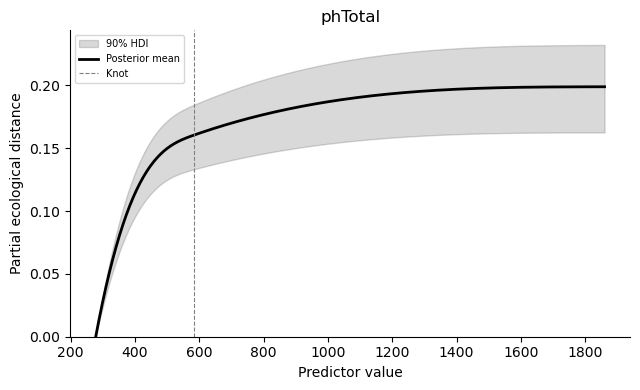

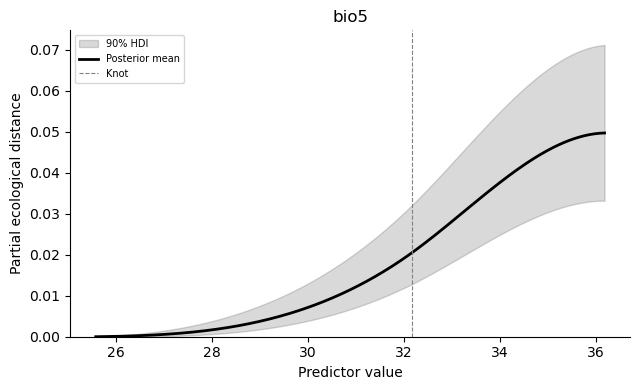

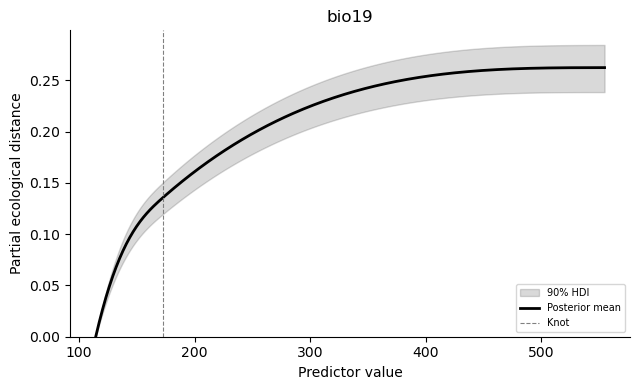

In [8]:
ispline_figs = plot_isplines(model, hdi_prob=0.9)
for (fig, ax) in ispline_figs:
    feature = ax.get_title() or ax.get_xlabel()
    fig.savefig(FIG_DIR / f"sw_ispline_{feature}.pdf")
plt.show()

### 5b. Posterior predictor importance

Bayesian analogue of R `gdm::gdm.varImp`. Bars are posterior means with HDI
intervals; the height equals `sum_j beta[k, j]` (I-splines saturate to 1).

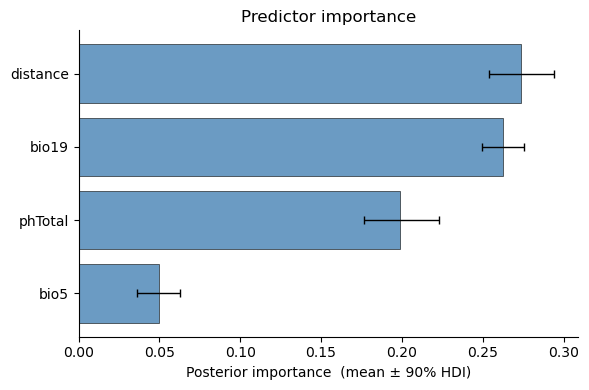

In [9]:
fig, ax = plot_predictor_importance(model, hdi_prob=0.9, include_distance=True)
fig.savefig(FIG_DIR / "sw_predictor_importance.pdf")
plt.show()

### 5c. Observed vs. predicted and link curve

Two fit diagnostics that mirror R `gdm::plot.gdm` panels 1 and 2:

- **Obs vs. pred** — scatter on the Bray–Curtis scale with the 1:1 line.
- **Link curve** — observed dissimilarity against the linear predictor
  (`eta`) with the model's implied `1 − exp(−eta)` link.

Sampling: [log_y]


Output()

Sampling: [log_y]


Output()

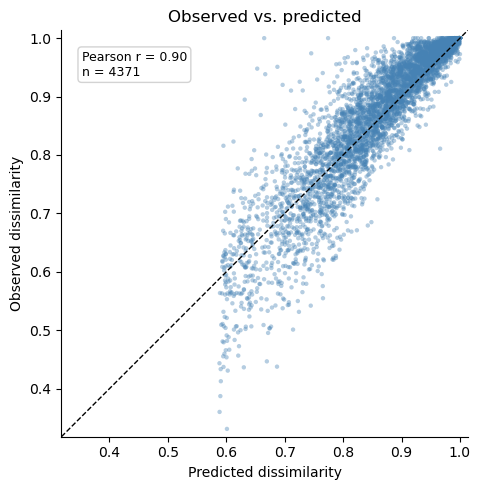

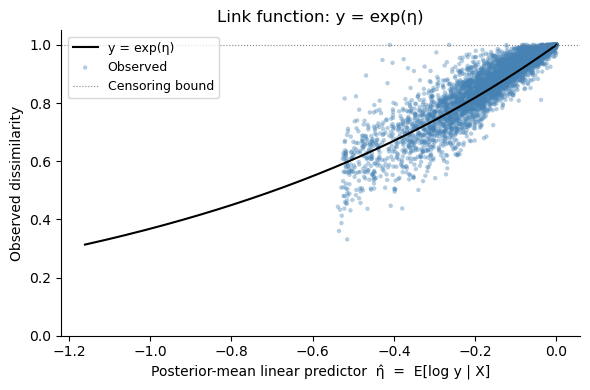

In [10]:
fig_op, _ = plot_obs_vs_pred(model, X, y)
fig_op.savefig(FIG_DIR / "sw_obs_vs_pred.pdf")

fig_lc, _ = plot_link_curve(model, X, y)
fig_lc.savefig(FIG_DIR / "sw_link_curve.pdf")
plt.show()

### 5d. Posterior predictive check

Overlay of the observed `y` distribution against samples from the posterior
predictive. A well-calibrated model has the observed density within the
posterior predictive envelope.

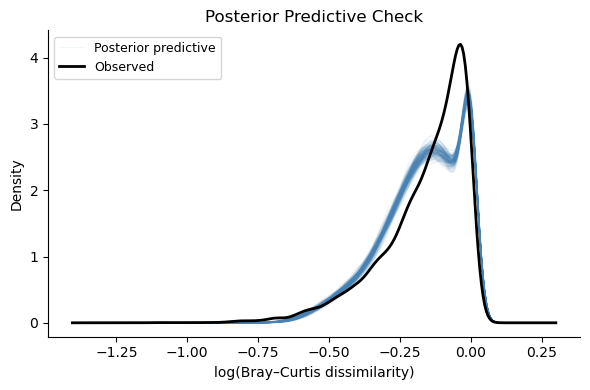

In [11]:
fig_ppc, _ = plot_ppc(model.idata_, y)
fig_ppc.savefig(FIG_DIR / "sw_ppc.pdf")
plt.show()

### 5e. Biological-space RGB map

GDM's community-composition map: transform each site through the fitted
I-splines, project to the top 3 PCs, and rescale to RGB. Sites with similar
predicted community composition get similar colours. We evaluate at the 94
site locations (a continuous climate grid would require interpolating the three
predictors off-site, which is outside this running example).

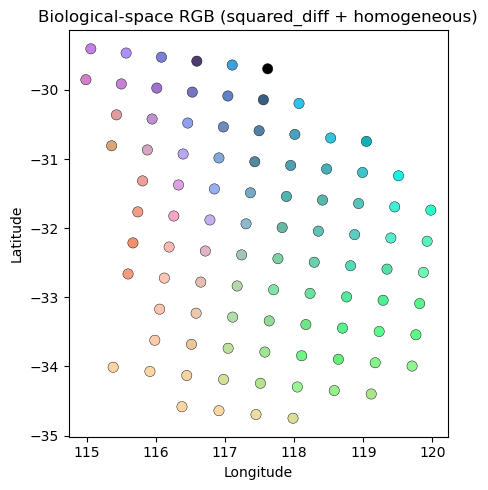

In [12]:
X_rgb = X.copy()
X_rgb.index = pd.MultiIndex.from_arrays(
    [X_rgb["yc"].to_numpy(), X_rgb["xc"].to_numpy()], names=["yc", "xc"]
)
rgb = rgb_biological_space(model.idata_, X_rgb, metric="median")

# rgb has dims (time, xc, yc, rgb); pull out per-site colours for a scatter.
rgb_site = rgb.isel(time=0).stack(site=("yc", "xc")).dropna("site", how="all")
colours = np.clip(rgb_site.transpose("site", "rgb").to_numpy(), 0, 1)
coords = np.asarray(rgb_site["site"].to_numpy().tolist())  # (n_site, 2) = (yc, xc)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(coords[:, 1], coords[:, 0], c=colours, s=55, edgecolor="k", lw=0.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Biological-space RGB (squared_diff + homogeneous)")
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "sw_biological_space_rgb.pdf")
plt.show()

## 6. CV metrics vs. White et al. (2024) Table 1

The table below lists White's published 10-fold CV benchmarks for SW so the
manuscript figures have the baseline numbers at hand. If a full Bayesian CV
sweep (9 configs × 10 folds) has been written to
`results/southwest/southwest_cv_metrics.csv` (e.g. by a dedicated CV driver),
the cell merges our numbers in; otherwise it just shows White's reference
values.

In [13]:
WHITE_TABLE1 = pd.DataFrame(
    [
        ("none", "homogeneous", 0.0439, 0.0790, 0.0595),
        ("none", "covariate_dependent", 0.0435, 0.0805, 0.0608),
        ("abs_diff", "homogeneous", 0.0473, 0.0840, 0.0629),
        ("abs_diff", "covariate_dependent", 0.0454, 0.0820, 0.0626),
        ("squared_diff", "homogeneous", 0.0414, 0.0731, 0.0545),
        ("squared_diff", "covariate_dependent", 0.0407, 0.0748, 0.0556),
    ],
    columns=["spatial_effect", "variance", "CRPS_White", "RMSE_White", "MAE_White"],
)

metrics_path = RESULTS_DIR / "southwest_cv_metrics.csv"
if metrics_path.exists():
    ours = pd.read_csv(metrics_path)
    merged = WHITE_TABLE1.merge(
        ours[["spatial_effect", "variance", "RMSE_CV", "MAE_CV", "CRPS_CV"]],
        on=["spatial_effect", "variance"],
        how="left",
    )
    merged["RMSE_delta"] = merged["RMSE_CV"] - merged["RMSE_White"]
    merged["MAE_delta"] = merged["MAE_CV"] - merged["MAE_White"]
    merged["CRPS_delta"] = merged["CRPS_CV"] - merged["CRPS_White"]
    display(merged.round(4))
    merged.round(4).to_csv(FIG_DIR / "sw_table1_comparison.csv", index=False)
else:
    print(f"(No Bayesian CV metrics yet at {metrics_path} — showing White's reference values only.)")
    display(WHITE_TABLE1)

(No Bayesian CV metrics yet at /cluster/home/haroldh/spgdmm/results/southwest/southwest_cv_metrics.csv — showing White's reference values only.)


,spatial_effect,variance,CRPS_White,RMSE_White,MAE_White
0,none,homogeneous,0.0439,0.0790,0.0595
1,none,covariate_dependent,0.0435,0.0805,0.0608
2,abs_diff,homogeneous,0.0473,0.0840,0.0629
3,abs_diff,covariate_dependent,0.0454,0.0820,0.0626
4,squared_diff,homogeneous,0.0414,0.0731,0.0545
5,squared_diff,covariate_dependent,0.0407,0.0748,0.0556


## 7. CRPS-by-fold boxplot (optional)

If we also have a per-fold predictions file we can draw the CRPS boxplot used
in the manuscript. Otherwise skip — this cell is a no-op.

In [14]:
fold_csv = RESULTS_DIR / "southwest_cv_fold_metrics.csv"
if fold_csv.exists():
    fold_df = pd.read_csv(fold_csv)
    fig, ax = crps_boxplot(fold_df)
    fig.savefig(FIG_DIR / "sw_crps_boxplot.pdf")
    plt.show()
else:
    print(f"(No per-fold file at {fold_csv} — skipping CRPS boxplot.)")

(No per-fold file at /cluster/home/haroldh/spgdmm/results/southwest/southwest_cv_fold_metrics.csv — skipping CRPS boxplot.)


## 8. Figure inventory

Everything the notebook dropped into `paper/figures/southwest/` — this is the
set of files to reference from `paper/manuscript.tex`.

In [15]:
for p in sorted(FIG_DIR.iterdir()):
    print(f"  {p.relative_to(REPO_ROOT)}")

  paper/figures/southwest/sw_biological_space_rgb.pdf
  paper/figures/southwest/sw_ispline_bio19.pdf
  paper/figures/southwest/sw_ispline_bio5.pdf
  paper/figures/southwest/sw_ispline_phTotal.pdf
  paper/figures/southwest/sw_link_curve.pdf
  paper/figures/southwest/sw_obs_vs_pred.pdf
  paper/figures/southwest/sw_ppc.pdf
  paper/figures/southwest/sw_predictor_importance.pdf
  paper/figures/southwest/sw_site_map.pdf
